In [1]:
import sys, os, pickle, random

import numpy as np
import matplotlib.pyplot as plt
import pickle

from resplan_utils import (
    CATEGORY_COLORS,
    normalize_keys, get_plan_width,
    get_geometries, centroid,
    geometry_to_mask,
    augment_geom,
    buffer_shrink_expand, buffer_expand_shrink,
    plot_plan,
    plan_to_graph, plot_plan_and_graph
)

from resplan_utils import *

# plt.rcParams['figure.dpi'] = 110

In [2]:
# By default, we load from /mnt/data. Change DATA_PATH if needed.
DATA_PATH = 'ResPlan.pkl'

with open(DATA_PATH, 'rb') as f:
    plans = pickle.load(f)

print(f'Loaded {len(plans)} plans')
# Peek at keys of the first plan
example = plans[0]
print('Sample keys:', list(example.keys())[:20])

# Normalize common key typos (e.g., balacony -> balcony) in-place for safety
for p in plans:
    normalize_keys(p)

Loaded 17107 plans
Sample keys: ['balcony', 'bathroom', 'bedroom', 'door', 'garden', 'inner', 'parking', 'pool', 'stair', 'veranda', 'wall', 'window', 'front_door', 'unitType', 'id', 'kitchen', 'land', 'net_area', 'area', 'storage']


In [3]:
# idx = random.randrange(len(plans))
# plan = plans[idx]

# ax = plot_plan(plan, title=f'Plan #{idx}')
# plt.show()

# img = get_2d_plan(plan, show=True)

/opt/dlami/nvme/mitunet_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/mitunet/seg_graph_worker.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setti

Total components found (excl. background): 8
  [KEEP] comp 1: area= 109945, bbox=(4,4,512,320)
  [KEEP] comp 2: area=  19159, bbox=(220,4,128,166)
  [KEEP] comp 3: area=   8316, bbox=(6,239,132,63)
  [KEEP] comp 4: area=  23520, bbox=(420,271,96,245)
  [KEEP] comp 5: area=  25535, bbox=(34,312,152,168)
  [KEEP] comp 6: area=  26899, bbox=(264,316,146,200)
  [KEEP] comp 7: area=   6106, bbox=(196,334,59,104)
  [KEEP] comp 8: area=   3944, bbox=(196,448,58,68)
Detected 8 rooms
  Room  1: bbox=(4, 4, 512, 320), centroid=(265, 153), area=109945
  Room  2: bbox=(220, 4, 128, 166), centroid=(287, 93), area=19159
  Room  3: bbox=(6, 239, 132, 63), centroid=(71, 270), area=8316
  Room  4: bbox=(420, 271, 96, 245), centroid=(467, 393), area=23520
  Room  5: bbox=(34, 312, 152, 168), centroid=(109, 395), area=25535
  Room  6: bbox=(264, 316, 146, 200), centroid=(336, 408), area=26899
  Room  7: bbox=(196, 334, 59, 104), centroid=(224, 385), area=6106
  Room  8: bbox=(196, 448, 58, 68), centroid=

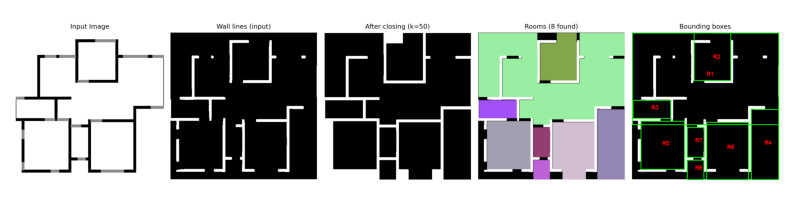

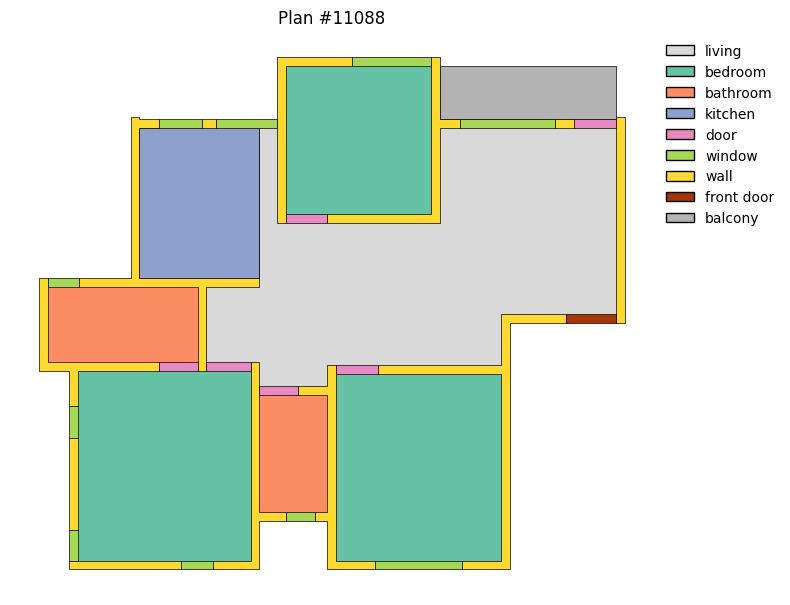

In [3]:
# idx = random.randrange(len(plans))
idx = 11088
plan = plans[idx]

SHAPE = (512, 512)

img = get_2d_plan(plan, show=False)
img_path = f'plans/plan_{idx}.png'
cv2.imwrite(img_path, img)

from seg_graph_worker import build_graph, build_graph_from_mask, predict, find_room_boundaries

build_graph(img_path, border=3, kernel_size=50, iterations=1)
# plot room_detection.png image
img = cv2.imread('room_detection.png')
# set fig size to 10x10 inches
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

ax = plot_plan(plan, title=f'Plan #{idx}')
plt.show()


Total components found (excl. background): 12
  [KEEP] comp 1: area=  21537, bbox=(4,4,85,306)
  [skip] comp 2: area=  90970, bbox=(4,4,512,512)
  [KEEP] comp 3: area=   8278, bbox=(95,87,101,83)
  [KEEP] comp 4: area=   7771, bbox=(198,87,122,82)
  [KEEP] comp 5: area=   3143, bbox=(46,90,42,75)
  [KEEP] comp 6: area=  26282, bbox=(95,216,201,200)
  [KEEP] comp 7: area=   6315, bbox=(335,254,87,73)
  [KEEP] comp 8: area=   4561, bbox=(45,296,43,107)
  [KEEP] comp 9: area=   3524, bbox=(298,328,58,61)
  [KEEP] comp 10: area=   5120, bbox=(359,328,63,88)
  [KEEP] comp 11: area=   2009, bbox=(95,329,41,49)
  [KEEP] comp 12: area=   2206, bbox=(138,368,46,48)
Detected 11 rooms
  Room  1: bbox=(4, 4, 85, 306), centroid=(41, 156), area=21537
  Room  2: bbox=(95, 87, 101, 83), centroid=(144, 127), area=8278
  Room  3: bbox=(198, 87, 122, 82), centroid=(249, 121), area=7771
  Room  4: bbox=(46, 90, 42, 75), centroid=(66, 127), area=3143
  Room  5: bbox=(95, 216, 201, 200), centroid=(215, 314)

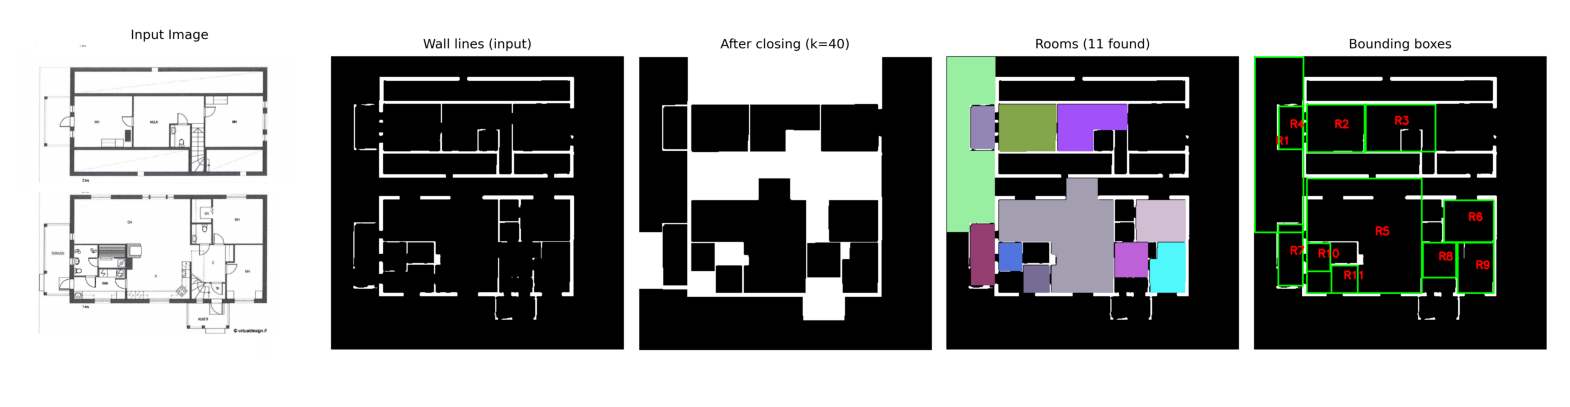

In [4]:
from seg_graph_worker import build_graph, build_graph_from_mask, predict, find_room_boundaries
# img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/page30_img17584.png"
# img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/plans/page31_img17587.png"
# img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/clstr_aparna_2.png"
# img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/plans/page14_img32.png"
img_path = "test_images/test_image_2.png"

# build_graph(img_path, border=3, kernel_size=30, iterations=1, min_room_area = 10, max_room_area=50000)
build_graph(img_path, border=3, kernel_size=40, iterations=1, min_room_area = 10, max_room_area=50000)
# plot room_detection.png image
img = cv2.imread('room_detection.png')
# set fig size to 10x10 inches
plt.figure(figsize=(20, 20))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Total components found (excl. background): 12
  [KEEP] comp 1: area=   4800, bbox=(4,4,100,48)
  [KEEP] comp 2: area=   3868, bbox=(202,4,46,85)
  [KEEP] comp 3: area=  26338, bbox=(291,4,225,140)
  [KEEP] comp 4: area=   6323, bbox=(91,54,109,70)
  [KEEP] comp 5: area=   1933, bbox=(472,147,44,44)
  [KEEP] comp 6: area=  39125, bbox=(4,156,174,360)
  [skip] comp 7: area=  68542, bbox=(198,193,318,323)
  [KEEP] comp 8: area=   2300, bbox=(386,235,46,50)
  [KEEP] comp 9: area=   2906, bbox=(167,248,57,51)
  [KEEP] comp 10: area=   3640, bbox=(227,254,57,64)
  [KEEP] comp 11: area=   4129, bbox=(286,268,68,61)
  [KEEP] comp 12: area=   1880, bbox=(98,374,40,47)
Detected 11 rooms
  Room  1: bbox=(4, 4, 100, 48), centroid=(53, 27), area=4800
  Room  2: bbox=(202, 4, 46, 85), centroid=(224, 46), area=3868
  Room  3: bbox=(291, 4, 225, 140), centroid=(410, 65), area=26338
  Room  4: bbox=(91, 54, 109, 70), centroid=(142, 89), area=6323
  Room  5: bbox=(472, 147, 44, 44), centroid=(493, 168),

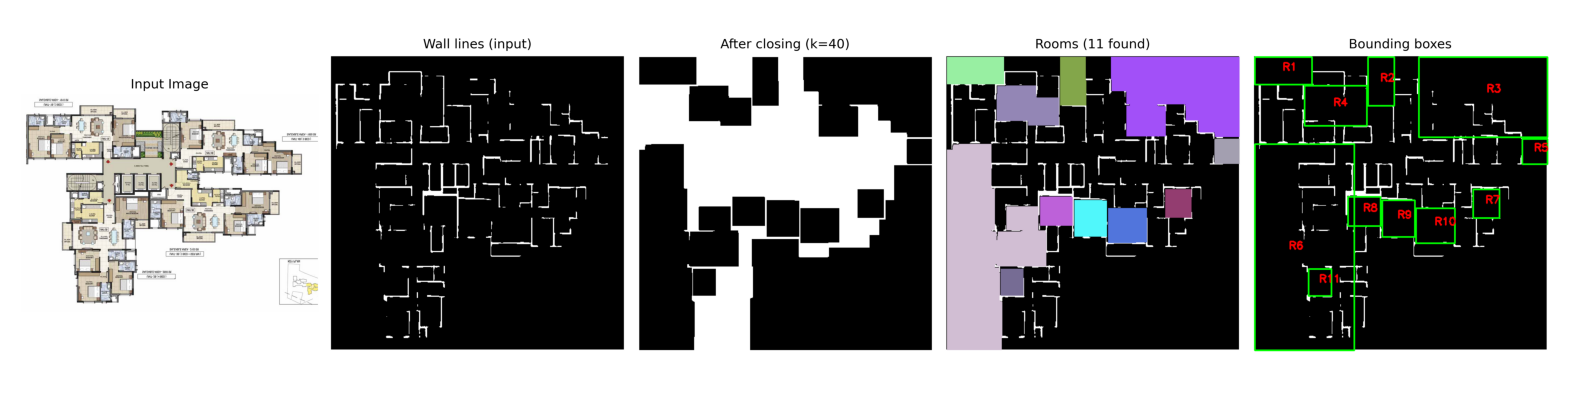

In [24]:
from seg_graph_worker import build_graph, build_graph_from_mask, predict, find_room_boundaries
img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/plans/page30_img17584.png"
# img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/plans/page31_img17587.png"
# img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/clstr_aparna_2.png"
# img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/plans/page14_img32.png"
# img_path = "test_images/test_image_2.png"

# build_graph(img_path, border=3, kernel_size=30, iterations=1, min_room_area = 10, max_room_area=50000)
build_graph(img_path, border=3, kernel_size=40, iterations=1, min_room_area = 10, max_room_area=50000)
# plot room_detection.png image
img = cv2.imread('room_detection.png')
# set fig size to 10x10 inches
plt.figure(figsize=(20, 20))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [19]:
def validate_graph(plan: Dict[str, Any],
                   rooms: List[Dict],
                   pred_graph: Dict,
                   shape: Tuple[int, int] = (512, 512),
                   iou_threshold: float = 0.5) -> Dict[str, Any]:
    """
    Validate predicted rooms/graph against ground-truth plan.

    Args:
        plan          : resplan plan dict (shapely geometries)
        rooms         : room list — MUST be from the same find_room_boundaries
                        call that produced pred_graph (same border/kernel params)
        pred_graph    : graph dict from build_graph_from_mask()
        shape         : canvas size the prediction was done at (H, W) = (512,512)
        iou_threshold : min IoU to count as TP
    """
    from scipy.optimize import linear_sum_assignment

    H, W = shape
    plan = normalize_keys(plan)

    # ── 1. GT nodes ───────────────────────────────────────────────────────────
    gt_graph  = plan_to_graph(plan)
    room_cats = {"living", "bedroom", "bathroom", "kitchen", "balcony"}
    gt_nodes  = [(nid, d) for nid, d in gt_graph.nodes(data=True)
                 if d.get("type") in room_cats]

    if not gt_nodes or not rooms:
        return {"error": "No GT nodes or predicted rooms to compare."}

    # ── 2. Build the same coordinate transform that the prediction pipeline uses
    #
    #   get_2d_plan does:
    #     geometry_to_mask(geom, shape=DEFAULT_CANVAS_SIZE)
    #     → np.flipud                    ← user added this
    #     → crop to non-background bbox  ← if user added the crop fix
    #     → saved to disk
    #   model then does A.Resize(512, 512)
    #
    #   We replicate the exact same steps for every GT room mask.
    # ─────────────────────────────────────────────────────────────────────────

    src = DEFAULT_CANVAS_SIZE          # (256, 256) — same shape used in get_2d_plan

    # Run get_2d_plan once (walls only) to detect crop bounds
    plan_render = get_2d_plan(plan, shape=src, show=False)   # has flipud inside
    bg = 255
    ys, xs = np.where(plan_render != bg)
    if len(ys) and len(xs):
        cy1, cy2 = int(ys.min()), int(ys.max()) + 1
        cx1, cx2 = int(xs.min()), int(xs.max()) + 1
    else:                              # no crop — use full canvas
        cy1, cy2 = 0, src[0]
        cx1, cx2 = 0, src[1]

    def _gt_mask(geom) -> np.ndarray:
        """Rasterise one GT room with the exact same transform as get_2d_plan."""
        mask = geometry_to_mask(geom, shape=src)   # raw plan coords → canvas
        mask = np.flipud(mask)                     # match get_2d_plan's flipud
        mask = mask[cy1:cy2, cx1:cx2]              # same crop
        mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)
        return (mask > 0).astype(np.uint8) * 255

    # ── 3. Rasterise GT rooms ─────────────────────────────────────────────────
    gt_masks, gt_nids, gt_types = [], [], []
    for nid, d in gt_nodes:
        geom = d["geometry"]
        if geom is None or geom.is_empty:
            continue
        gt_masks.append(_gt_mask(geom))
        gt_nids.append(nid)
        gt_types.append(d["type"])

    # ── 4. Rasterise predicted rooms ──────────────────────────────────────────
    pred_masks = []
    for r in rooms:
        m = np.zeros((H, W), dtype=np.uint8)
        if r["contour"] is not None:
            cv2.fillPoly(m, [r["contour"]], 255)
        pred_masks.append(m)

    # ── 5. IoU matrix ─────────────────────────────────────────────────────────
    n_gt, n_pred = len(gt_masks), len(pred_masks)
    iou_mat = np.zeros((n_gt, n_pred), dtype=float)
    for i, gm in enumerate(gt_masks):
        for j, pm in enumerate(pred_masks):
            inter = np.logical_and(gm > 0, pm > 0).sum()
            union = np.logical_or(gm > 0, pm > 0).sum()
            iou_mat[i, j] = inter / union if union > 0 else 0.0

    print("IoU matrix (GT rows × Pred cols):\n", np.round(iou_mat, 2))

    # ── 6. Hungarian matching ─────────────────────────────────────────────────
    row_ind, col_ind = linear_sum_assignment(-iou_mat)
    matches = [(r, c, iou_mat[r, c])
               for r, c in zip(row_ind, col_ind)
               if iou_mat[r, c] >= iou_threshold]

    n_tp = len(matches)
    n_fp = n_pred - n_tp
    n_fn = n_gt   - n_tp
    prec = n_tp / (n_tp + n_fp) if (n_tp + n_fp) > 0 else 0.0
    rec  = n_tp / (n_tp + n_fn) if (n_tp + n_fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    miou = float(np.mean([m[2] for m in matches])) if matches else 0.0

    # ── 7. Edge validation ────────────────────────────────────────────────────
    gt_idx_to_pred   = {r: rooms[c]["id"] for r, c, _ in matches}
    matched_pred_ids = set(gt_idx_to_pred.values())

    gt_edge_set = set()
    for u, v in gt_graph.edges():
        if u in gt_nids and v in gt_nids:
            ui, vi = gt_nids.index(u), gt_nids.index(v)
            if ui in gt_idx_to_pred and vi in gt_idx_to_pred:
                a, b = gt_idx_to_pred[ui], gt_idx_to_pred[vi]
                gt_edge_set.add((min(a, b), max(a, b)))

    pred_edge_set = {(min(a, b), max(a, b))
                     for a, b in pred_graph["edges"]
                     if a in matched_pred_ids and b in matched_pred_ids}

    tp_e = len(gt_edge_set & pred_edge_set)
    fp_e = len(pred_edge_set - gt_edge_set)
    fn_e = len(gt_edge_set   - pred_edge_set)
    ep   = tp_e / (tp_e + fp_e) if (tp_e + fp_e) > 0 else 0.0
    er   = tp_e / (tp_e + fn_e) if (tp_e + fn_e) > 0 else 0.0
    ef   = 2 * ep * er / (ep + er) if (ep + er) > 0 else 0.0

    return {
        "room_tp":        n_tp,  "room_fp":  n_fp,  "room_fn":  n_fn,
        "room_precision": round(prec, 4),
        "room_recall":    round(rec,  4),
        "room_f1":        round(f1,   4),
        "mean_iou":       round(miou, 4),
        "edge_tp":        tp_e,  "edge_fp":  fp_e,  "edge_fn":  fn_e,
        "edge_precision": round(ep, 4),
        "edge_recall":    round(er, 4),
        "edge_f1":        round(ef, 4),
        "matches":        [(gt_nids[r], rooms[c]["id"], round(iou, 4))
                           for r, c, iou in matches],
    }

Total components found (excl. background): 8
  [skip] comp 1: area= 109945, bbox=(4,4,512,320)
  [KEEP] comp 2: area=  19159, bbox=(220,4,128,166)
  [KEEP] comp 3: area=   8316, bbox=(6,239,132,63)
  [KEEP] comp 4: area=  23520, bbox=(420,271,96,245)
  [KEEP] comp 5: area=  25535, bbox=(34,312,152,168)
  [KEEP] comp 6: area=  26899, bbox=(264,316,146,200)
  [KEEP] comp 7: area=   6106, bbox=(196,334,59,104)
  [KEEP] comp 8: area=   3944, bbox=(196,448,58,68)
Detected 7 rooms
  Room  1: bbox=(220, 4, 128, 166), centroid=(287, 93), area=19159
  Room  2: bbox=(6, 239, 132, 63), centroid=(71, 270), area=8316
  Room  3: bbox=(420, 271, 96, 245), centroid=(467, 393), area=23520
  Room  4: bbox=(34, 312, 152, 168), centroid=(109, 395), area=25535
  Room  5: bbox=(264, 316, 146, 200), centroid=(336, 408), area=26899
  Room  6: bbox=(196, 334, 59, 104), centroid=(224, 385), area=6106
  Room  7: bbox=(196, 448, 58, 68), centroid=(224, 481), area=3944
Graph:
Nodes:
  1: [[221, 40], [220, 169], [3

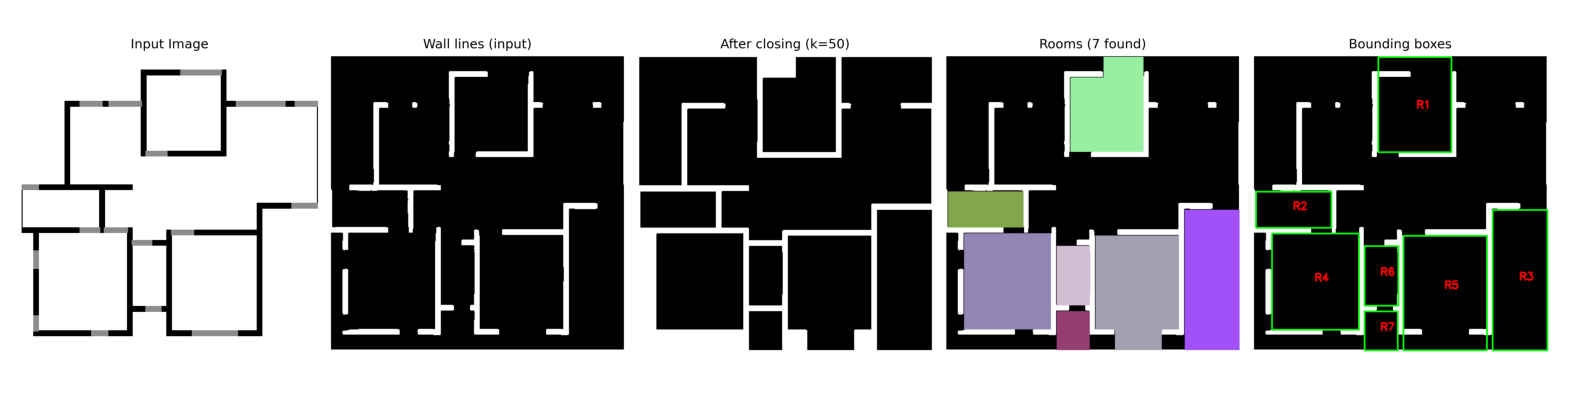

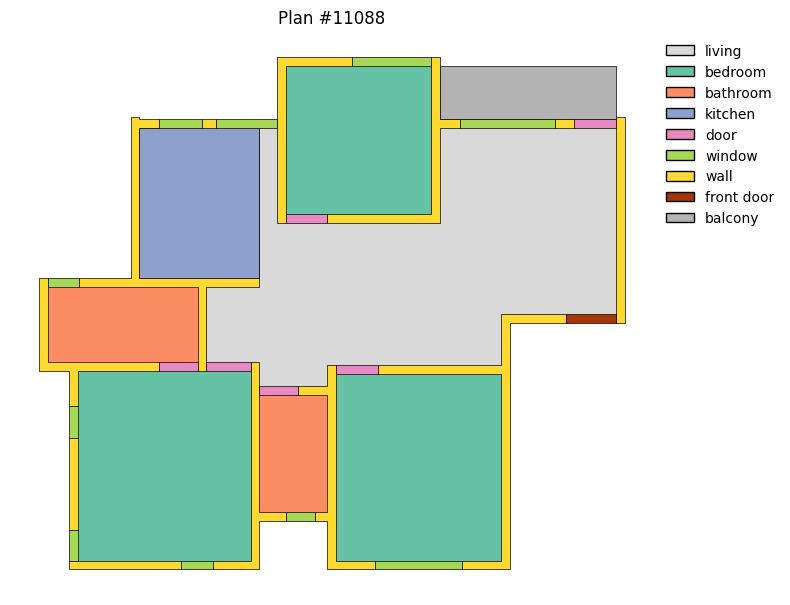

In [21]:
idx = 11088
plan = plans[idx]

SHAPE = (512, 512)

img = get_2d_plan(plan, show=False)
img_path = f'plans/plan_{idx}.png'
cv2.imwrite(img_path, img)

# pred_graph = build_graph(img_path)   # your existing function
pred_graph = build_graph(img_path, border=3, kernel_size=50, iterations=1, min_room_area = 10, max_room_area=50000)

img = cv2.imread('room_detection.png')
# set fig size to 10x10 inches

pred_wall = predict(img_path, show=False)  # your existing function
rooms      = find_room_boundaries(img_path, pred_wall, border=3, kernel_size=50, iterations=1, min_room_area=10, max_room_area=50000)  # already returns rooms
metrics    = validate_graph(plan, rooms, pred_graph, shape=(512, 512))
print(metrics)

plt.figure(figsize=(20, 20))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# plot the original plot_plan
ax = plot_plan(plan, title=f'Plan #{idx}')
plt.show()

Total components found (excl. background): 6
  [skip] comp 1: area= 141116, bbox=(4,4,512,408)
  [KEEP] comp 2: area=  16834, bbox=(260,132,119,142)
  [KEEP] comp 3: area=  18720, bbox=(304,282,144,130)
  [KEEP] comp 4: area=   4552, bbox=(458,282,57,80)
  [KEEP] comp 5: area=   4366, bbox=(218,324,78,56)
  [skip] comp 6: area=  51413, bbox=(4,391,512,125)
Detected 4 rooms
  Room  1: bbox=(260, 132, 119, 142), centroid=(318, 202), area=16834
  Room  2: bbox=(304, 282, 144, 130), centroid=(375, 346), area=18720
  Room  3: bbox=(458, 282, 57, 80), centroid=(485, 321), area=4552
  Room  4: bbox=(218, 324, 78, 56), centroid=(256, 351), area=4366
Graph:
Nodes:
  1: [[260, 132], [260, 273], [377, 273], [377, 132]]
  2: [[304, 282], [304, 411], [447, 411], [447, 282]]
  3: [[458, 282], [458, 361], [513, 361], [514, 283]]
  4: [[218, 325], [219, 379], [295, 379], [295, 324]]
Edges:
  1 <-> 2
  2 <-> 3
Total components found (excl. background): 6
  [skip] comp 1: area= 141116, bbox=(4,4,512,408

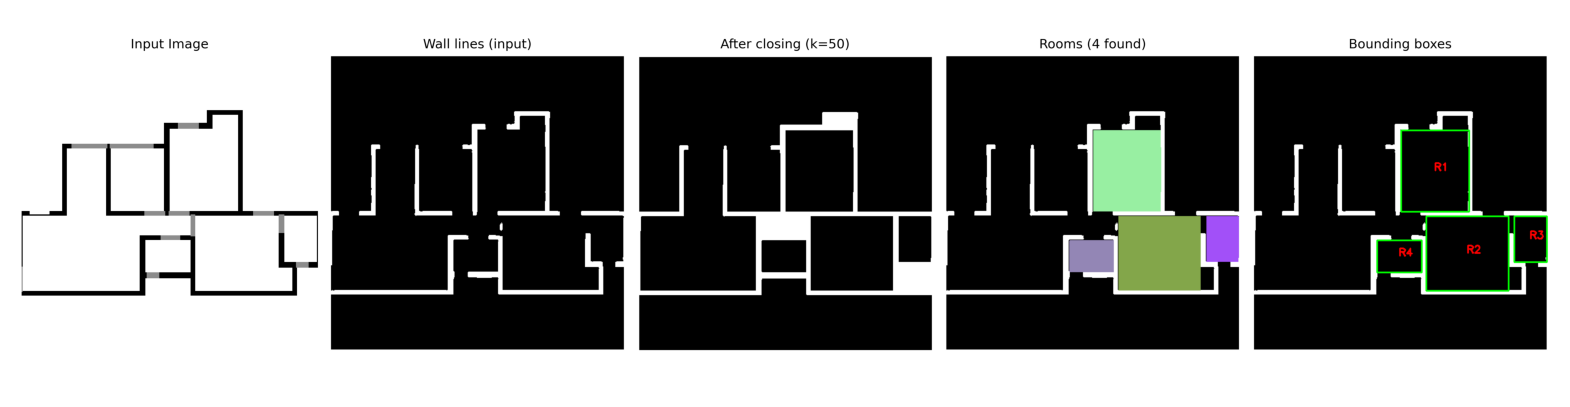

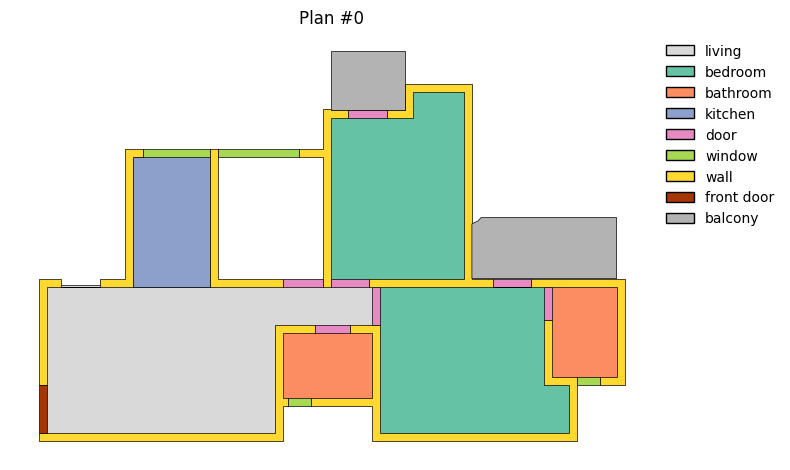

Total components found (excl. background): 9
  [KEEP] comp 1: area=  35675, bbox=(7,4,177,215)
  [KEEP] comp 2: area=  10290, bbox=(356,4,160,65)
  [KEEP] comp 3: area=  21903, bbox=(196,28,148,148)
  [skip] comp 4: area=  68864, bbox=(154,80,362,291)
  [KEEP] comp 5: area=   9126, bbox=(7,228,117,78)
  [KEEP] comp 6: area=  26395, bbox=(4,316,139,200)
  [KEEP] comp 7: area=  28753, bbox=(316,338,199,154)
  [KEEP] comp 8: area=   7651, bbox=(154,382,70,110)
  [KEEP] comp 9: area=   7699, bbox=(234,382,70,110)
Detected 8 rooms
  Room  1: bbox=(7, 4, 177, 215), centroid=(95, 116), area=35675
  Room  2: bbox=(356, 4, 160, 65), centroid=(435, 35), area=10290
  Room  3: bbox=(196, 28, 148, 148), centroid=(269, 101), area=21903
  Room  4: bbox=(7, 228, 117, 78), centroid=(65, 266), area=9126
  Room  5: bbox=(4, 316, 139, 200), centroid=(73, 414), area=26395
  Room  6: bbox=(316, 338, 199, 154), centroid=(409, 417), area=28753
  Room  7: bbox=(154, 382, 70, 110), centroid=(188, 436), area=765

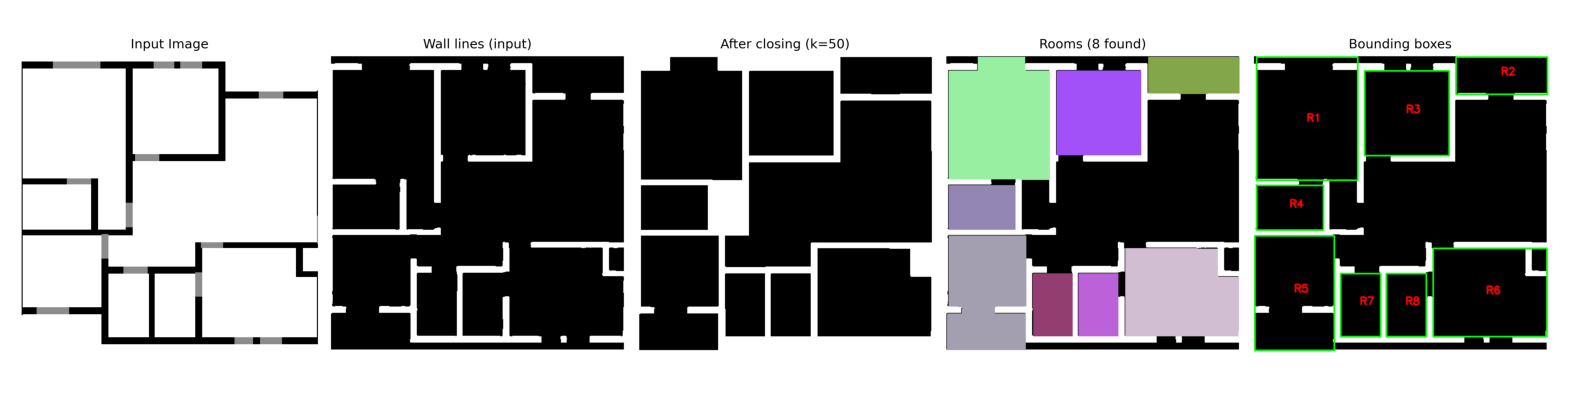

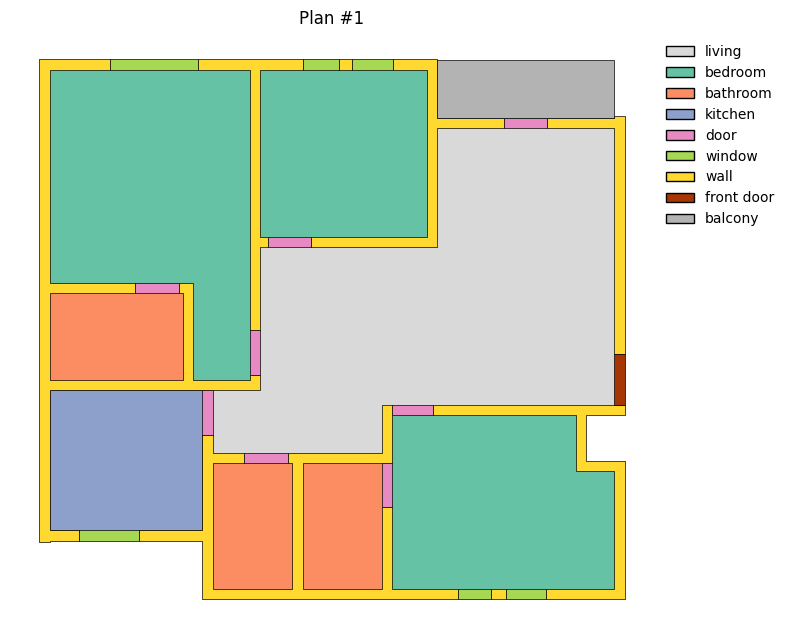

Total components found (excl. background): 5
  [skip] comp 1: area=  76009, bbox=(4,4,221,510)
  [skip] comp 2: area= 134159, bbox=(226,4,290,512)
  [KEEP] comp 3: area=   8787, bbox=(146,40,79,112)
  [KEEP] comp 4: area=   4158, bbox=(145,164,79,53)
  [KEEP] comp 5: area=   8579, bbox=(146,228,78,110)
Detected 3 rooms
  Room  1: bbox=(146, 40, 79, 112), centroid=(184, 95), area=8787
  Room  2: bbox=(145, 164, 79, 53), centroid=(183, 189), area=4158
  Room  3: bbox=(146, 228, 78, 110), centroid=(184, 282), area=8579
Graph:
Nodes:
  1: [[147, 40], [146, 150], [223, 151], [223, 40]]
  2: [[145, 166], [145, 215], [223, 215], [223, 164]]
  3: [[147, 228], [146, 337], [223, 337], [223, 228]]
Edges:
  1 <-> 2
  2 <-> 3
Total components found (excl. background): 5
  [skip] comp 1: area=  76009, bbox=(4,4,221,510)
  [skip] comp 2: area= 134159, bbox=(226,4,290,512)
  [KEEP] comp 3: area=   8787, bbox=(146,40,79,112)
  [KEEP] comp 4: area=   4158, bbox=(145,164,79,53)
  [KEEP] comp 5: area=   8

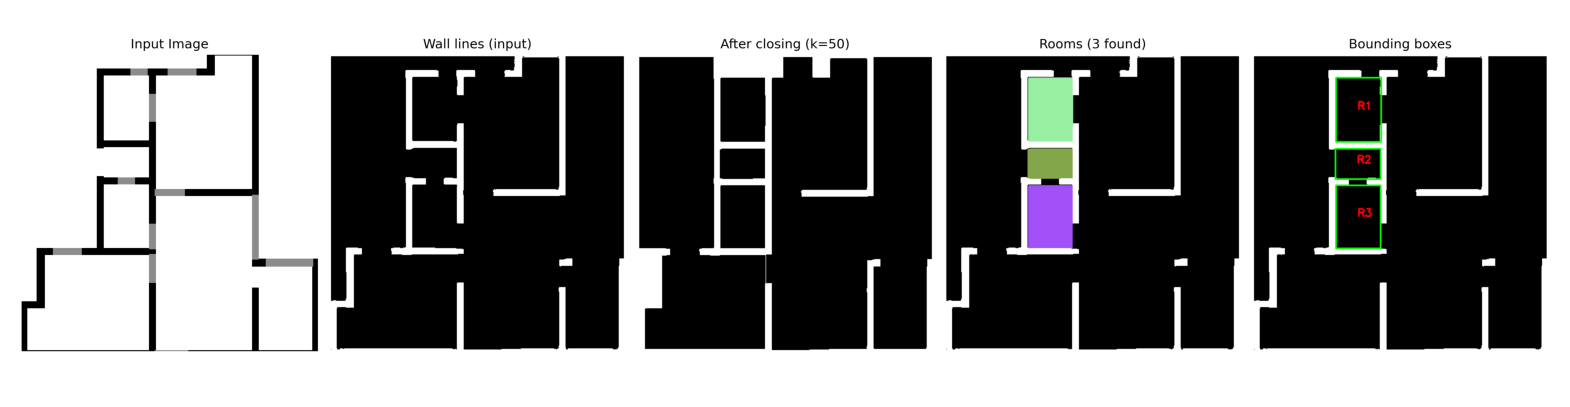

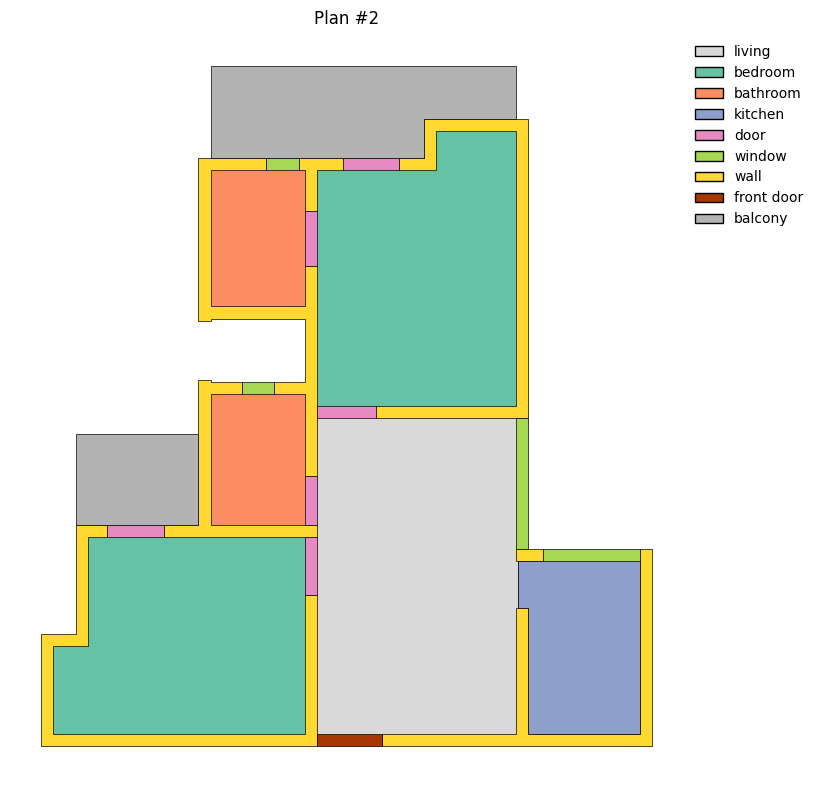

Total components found (excl. background): 9
  [KEEP] comp 1: area=  40919, bbox=(4,4,147,340)
  [skip] comp 2: area=  50163, bbox=(314,4,202,340)
  [KEEP] comp 3: area=  23317, bbox=(130,56,173,135)
  [KEEP] comp 4: area=   4755, bbox=(162,202,82,58)
  [KEEP] comp 5: area=  14136, bbox=(314,220,114,124)
  [KEEP] comp 6: area=  12679, bbox=(130,271,173,74)
  [KEEP] comp 7: area=  19211, bbox=(30,354,146,132)
  [KEEP] comp 8: area=  31043, bbox=(254,354,262,133)
  [KEEP] comp 9: area=   4987, bbox=(186,400,58,86)
Detected 8 rooms
  Room  1: bbox=(4, 4, 147, 340), centroid=(64, 176), area=40919
  Room  2: bbox=(130, 56, 173, 135), centroid=(216, 122), area=23317
  Room  3: bbox=(162, 202, 82, 58), centroid=(202, 230), area=4755
  Room  4: bbox=(314, 220, 114, 124), centroid=(370, 281), area=14136
  Room  5: bbox=(130, 271, 173, 74), centroid=(216, 307), area=12679
  Room  6: bbox=(30, 354, 146, 132), centroid=(102, 419), area=19211
  Room  7: bbox=(254, 354, 262, 133), centroid=(395, 415

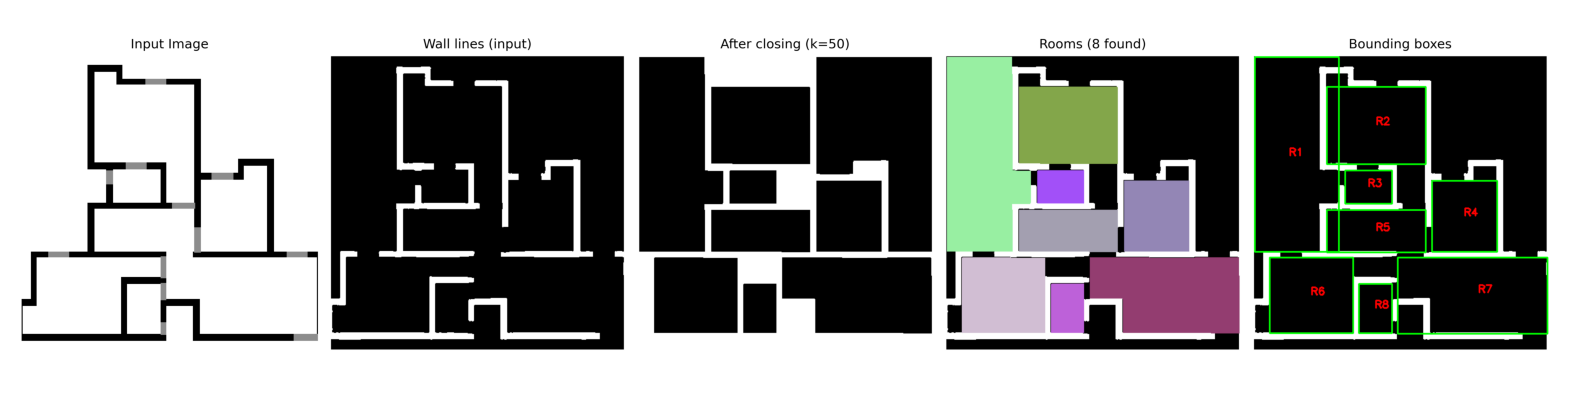

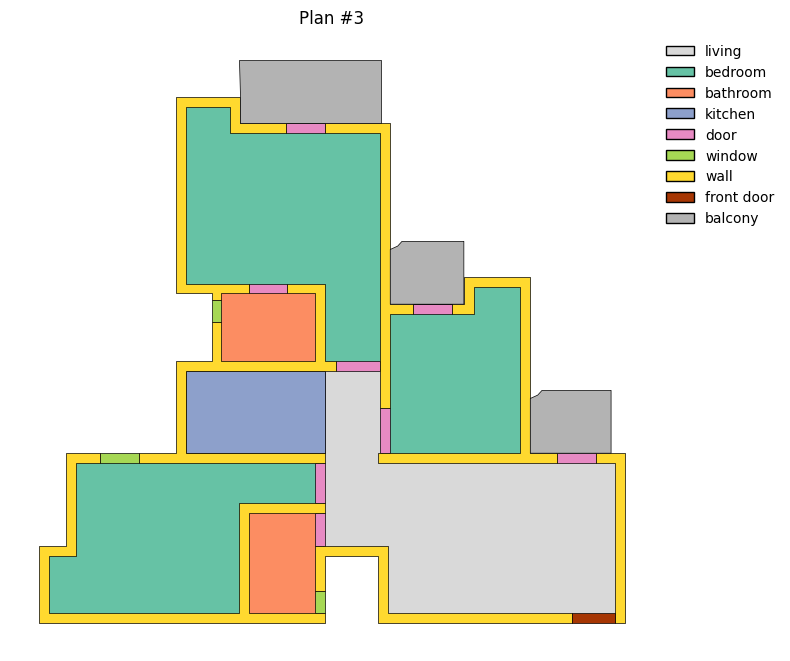

Total components found (excl. background): 7
  [skip] comp 1: area= 124081, bbox=(4,4,512,418)
  [KEEP] comp 2: area=   4628, bbox=(254,67,52,89)
  [KEEP] comp 3: area=  26366, bbox=(318,90,198,135)
  [KEEP] comp 4: area=   3240, bbox=(430,236,60,54)
  [KEEP] comp 5: area=  16428, bbox=(296,300,135,122)
  [KEEP] comp 6: area=   6888, bbox=(440,300,76,97)
  [KEEP] comp 7: area=  46752, bbox=(4,319,512,197)
Detected 6 rooms
  Room  1: bbox=(254, 67, 52, 89), centroid=(279, 111), area=4628
  Room  2: bbox=(318, 90, 198, 135), centroid=(415, 156), area=26366
  Room  3: bbox=(430, 236, 60, 54), centroid=(459, 262), area=3240
  Room  4: bbox=(296, 300, 135, 122), centroid=(362, 360), area=16428
  Room  5: bbox=(440, 300, 76, 97), centroid=(479, 349), area=6888
  Room  6: bbox=(4, 319, 512, 197), centroid=(246, 461), area=46752
Graph:
Nodes:
  1: [[254, 67], [254, 155], [305, 155], [305, 67]]
  2: [[318, 90], [318, 223], [515, 224], [515, 162], [489, 159], [514, 151], [513, 90]]
  3: [[430, 2

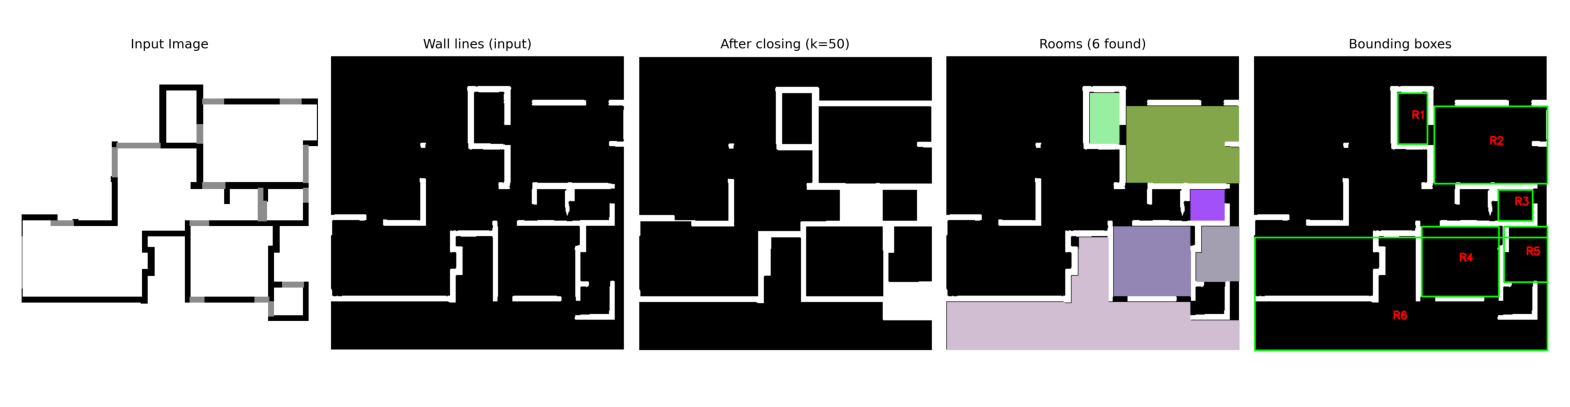

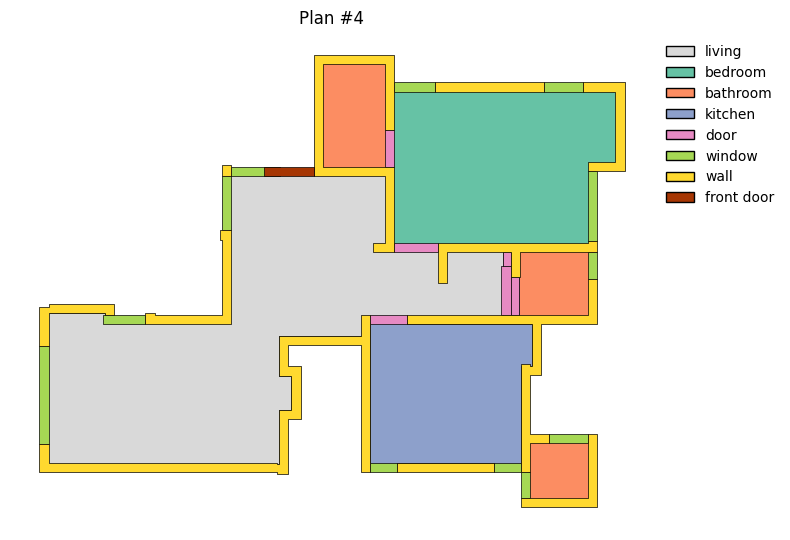

Total components found (excl. background): 7
  [KEEP] comp 1: area=  37436, bbox=(4,4,236,310)
  [KEEP] comp 2: area=  48419, bbox=(252,4,264,278)
  [skip] comp 3: area=  59813, bbox=(80,110,297,260)
  [KEEP] comp 4: area=  28677, bbox=(348,295,168,179)
  [KEEP] comp 5: area=  29263, bbox=(4,326,172,172)
  [KEEP] comp 6: area=   8002, bbox=(186,382,69,116)
  [KEEP] comp 7: area=   8119, bbox=(266,382,70,116)
Detected 6 rooms
  Room  1: bbox=(4, 4, 236, 310), centroid=(89, 118), area=37436
  Room  2: bbox=(252, 4, 264, 278), centroid=(416, 118), area=48419
  Room  3: bbox=(348, 295, 168, 179), centroid=(434, 387), area=28677
  Room  4: bbox=(4, 326, 172, 172), centroid=(90, 411), area=29263
  Room  5: bbox=(186, 382, 69, 116), centroid=(219, 439), area=8002
  Room  6: bbox=(266, 382, 70, 116), centroid=(300, 439), area=8119
Graph:
Nodes:
  1: [[239, 23], [4, 4], [4, 313], [67, 313], [66, 111], [182, 135], [183, 108], [239, 108]]
  2: [[252, 4], [252, 97], [388, 99], [388, 281], [515, 28

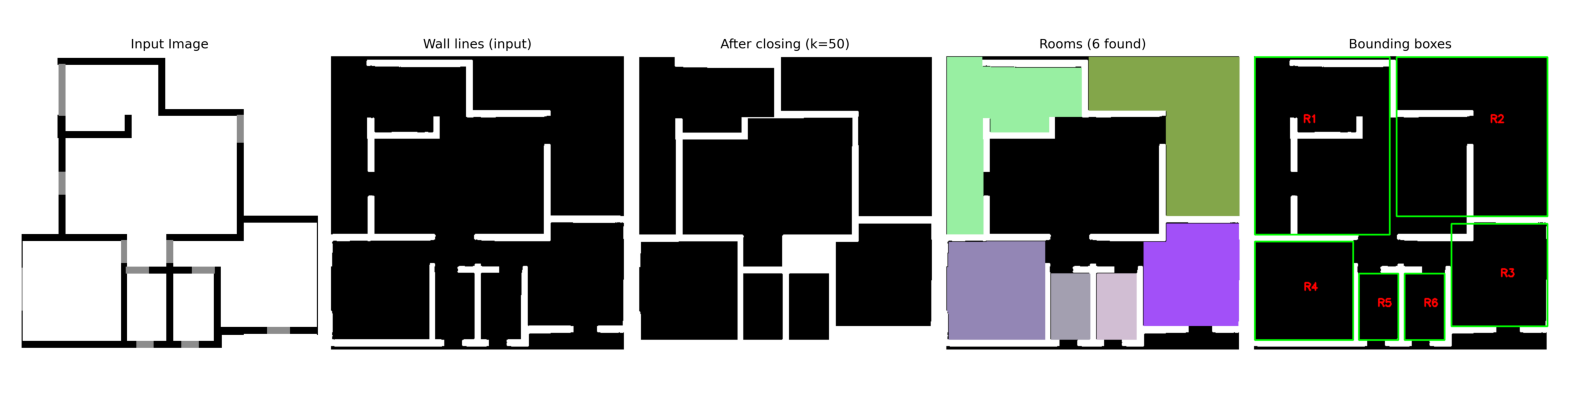

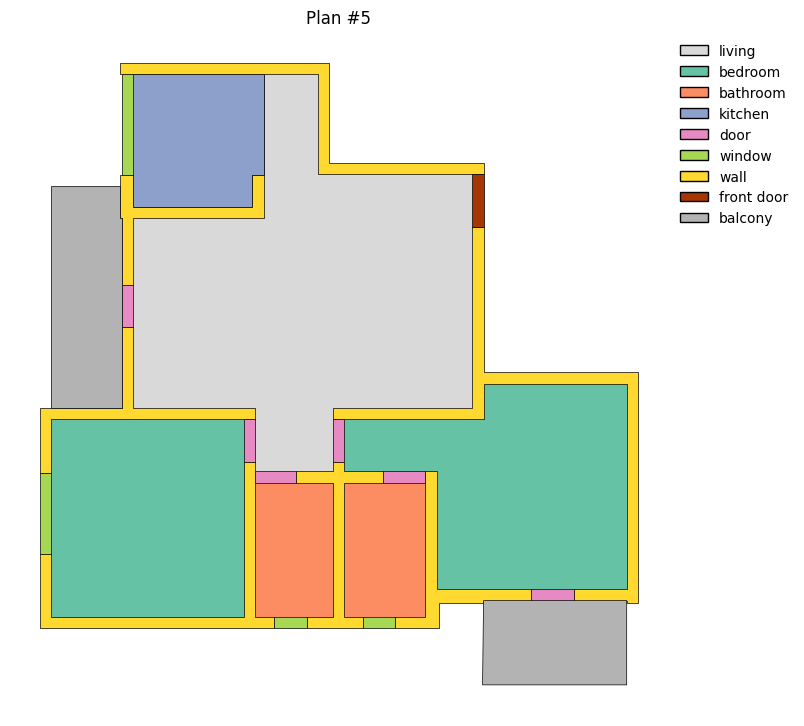

Total components found (excl. background): 8
  [skip] comp 1: area=  52635, bbox=(4,4,343,219)
  [KEEP] comp 2: area=  35224, bbox=(356,6,148,238)
  [KEEP] comp 3: area=  17285, bbox=(214,92,133,130)
  [KEEP] comp 4: area=  27001, bbox=(16,232,175,173)
  [KEEP] comp 5: area=  13072, bbox=(276,232,76,172)
  [KEEP] comp 6: area=   5612, bbox=(412,255,92,61)
  [KEEP] comp 7: area=   5951, bbox=(202,286,62,96)
  [skip] comp 8: area=  61511, bbox=(4,328,500,188)
Detected 6 rooms
  Room  1: bbox=(356, 6, 148, 238), centroid=(429, 124), area=35224
  Room  2: bbox=(214, 92, 133, 130), centroid=(280, 156), area=17285
  Room  3: bbox=(16, 232, 175, 173), centroid=(111, 321), area=27001
  Room  4: bbox=(276, 232, 76, 172), centroid=(313, 317), area=13072
  Room  5: bbox=(412, 255, 92, 61), centroid=(457, 285), area=5612
  Room  6: bbox=(202, 286, 62, 96), centroid=(232, 333), area=5951
Graph:
Nodes:
  1: [[356, 6], [356, 243], [503, 243], [503, 6]]
  2: [[214, 92], [214, 221], [346, 221], [345, 9

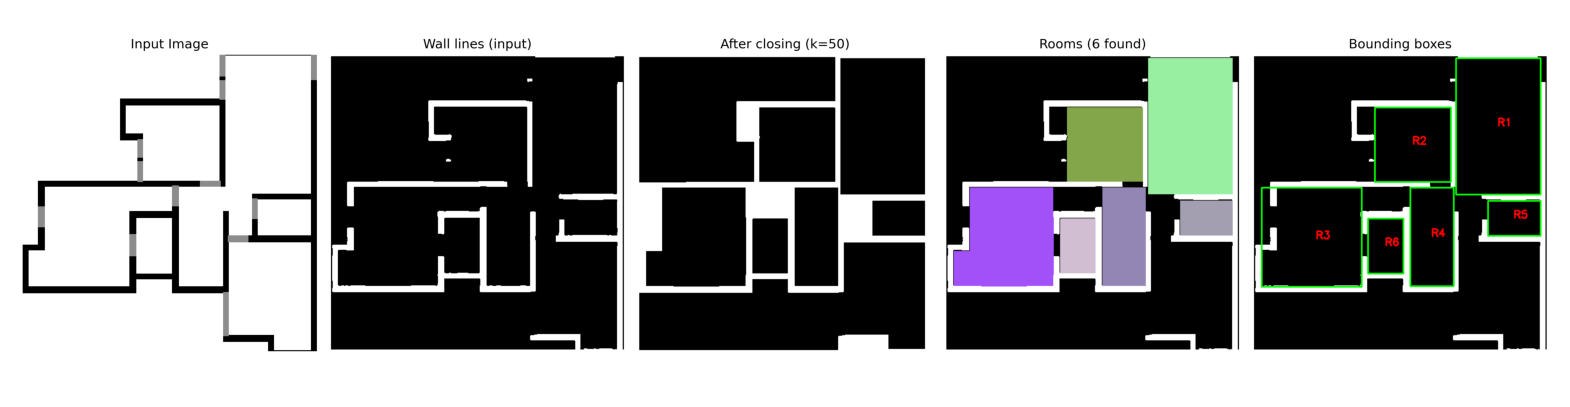

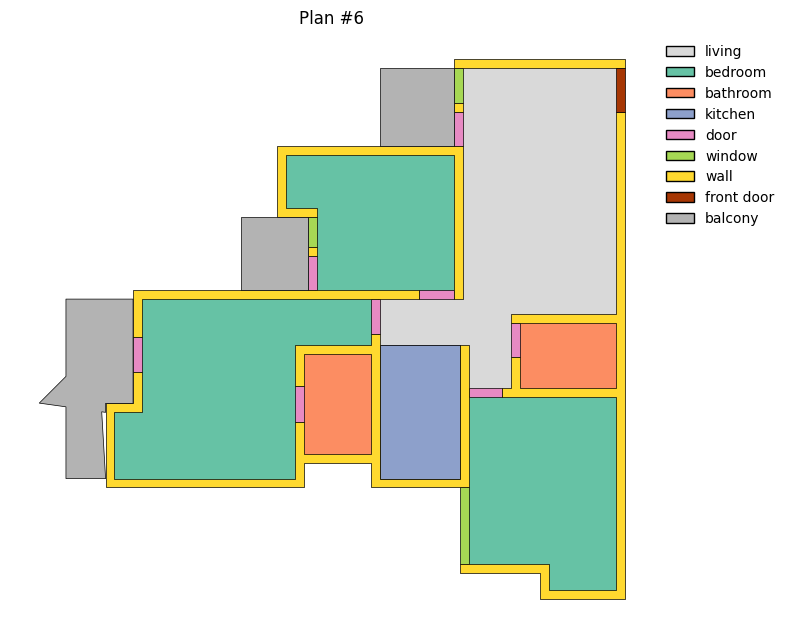

Total components found (excl. background): 9
  [KEEP] comp 1: area=  35427, bbox=(4,4,175,230)
  [KEEP] comp 2: area=  27847, bbox=(190,4,153,187)
  [KEEP] comp 3: area=  12956, bbox=(354,4,162,80)
  [skip] comp 4: area=  69912, bbox=(154,96,362,291)
  [KEEP] comp 5: area=   8430, bbox=(6,246,118,72)
  [KEEP] comp 6: area=  24820, bbox=(6,330,137,186)
  [KEEP] comp 7: area=  29573, bbox=(312,354,204,162)
  [KEEP] comp 8: area=   7533, bbox=(154,398,69,110)
  [KEEP] comp 9: area=   7479, bbox=(232,398,68,110)
Detected 8 rooms
  Room  1: bbox=(4, 4, 175, 230), centroid=(92, 130), area=35427
  Room  2: bbox=(190, 4, 153, 187), centroid=(266, 99), area=27847
  Room  3: bbox=(354, 4, 162, 80), centroid=(434, 43), area=12956
  Room  4: bbox=(6, 246, 118, 72), centroid=(64, 281), area=8430
  Room  5: bbox=(6, 330, 137, 186), centroid=(73, 420), area=24820
  Room  6: bbox=(312, 354, 204, 162), centroid=(406, 435), area=29573
  Room  7: bbox=(154, 398, 69, 110), centroid=(187, 452), area=7533
 

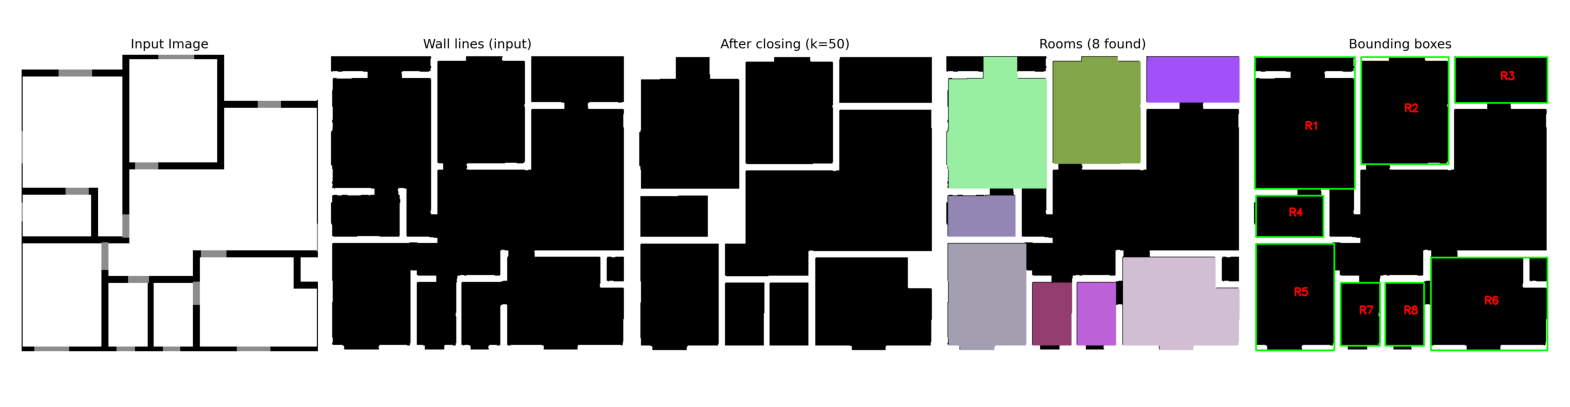

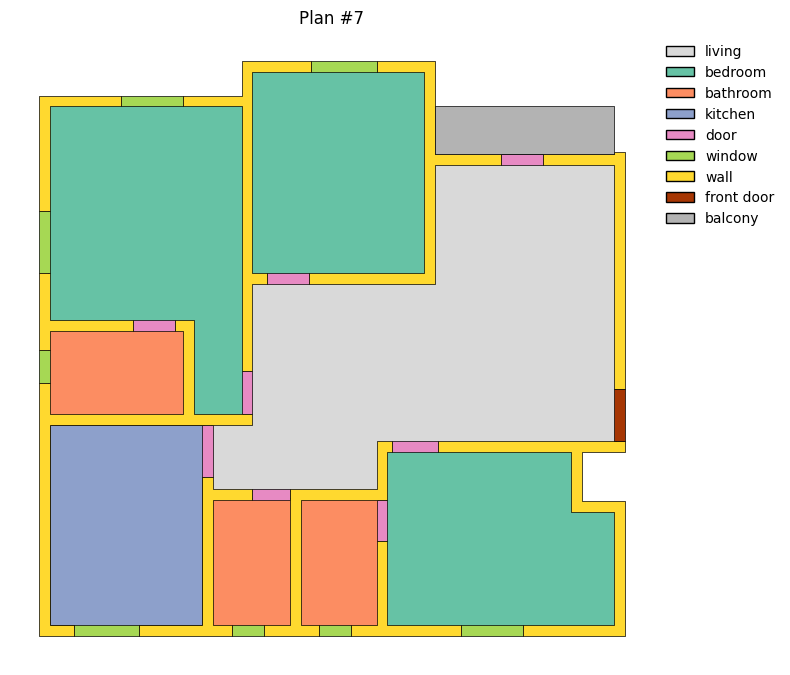

Total components found (excl. background): 2
  [skip] comp 1: area= 141881, bbox=(4,4,512,512)
  [skip] comp 2: area=  99284, bbox=(170,4,346,287)
Detected 0 rooms
Graph:
Nodes:
Edges:
Total components found (excl. background): 2
  [skip] comp 1: area= 141881, bbox=(4,4,512,512)
  [skip] comp 2: area=  99284, bbox=(170,4,346,287)
Detected 0 rooms
{'error': 'No GT nodes or predicted rooms to compare.'}


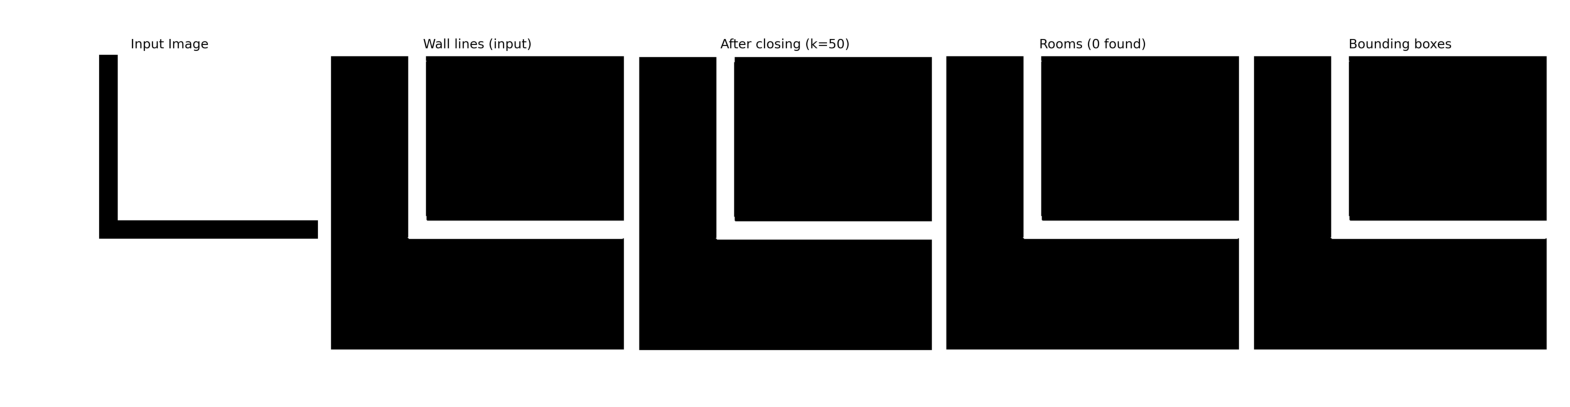

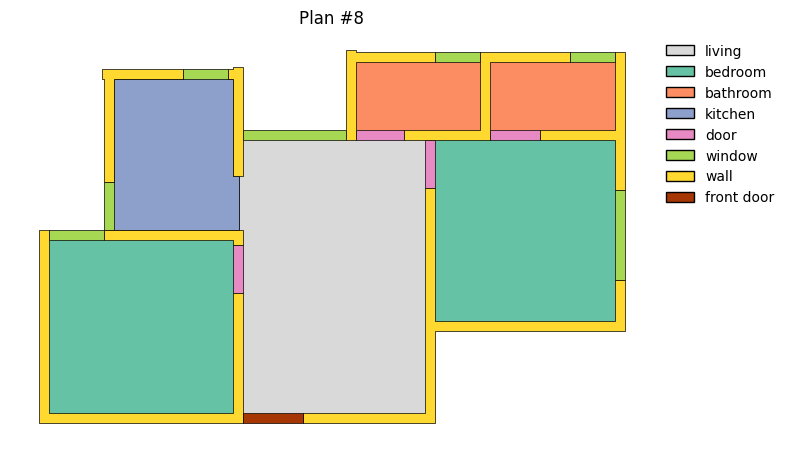

Total components found (excl. background): 7
  [skip] comp 1: area=  77246, bbox=(4,4,512,280)
  [KEEP] comp 2: area=  19700, bbox=(4,95,156,127)
  [KEEP] comp 3: area=  46987, bbox=(268,112,247,276)
  [KEEP] comp 4: area=   5032, bbox=(24,231,95,53)
  [KEEP] comp 5: area=   5878, bbox=(24,292,98,60)
  [KEEP] comp 6: area=  16963, bbox=(132,292,127,134)
  [skip] comp 7: area=  65439, bbox=(4,340,512,176)
Detected 5 rooms
  Room  1: bbox=(4, 95, 156, 127), centroid=(81, 158), area=19700
  Room  2: bbox=(268, 112, 247, 276), centroid=(358, 256), area=46987
  Room  3: bbox=(24, 231, 95, 53), centroid=(70, 256), area=5032
  Room  4: bbox=(24, 292, 98, 60), centroid=(72, 321), area=5878
  Room  5: bbox=(132, 292, 127, 134), centroid=(194, 358), area=16963
Graph:
Nodes:
  1: [[7, 95], [6, 221], [159, 221], [159, 95]]
  2: [[268, 113], [268, 387], [409, 387], [411, 331], [513, 331], [514, 259], [409, 256], [409, 112]]
  3: [[24, 231], [24, 283], [117, 283], [118, 231]]
  4: [[24, 293], [24, 3

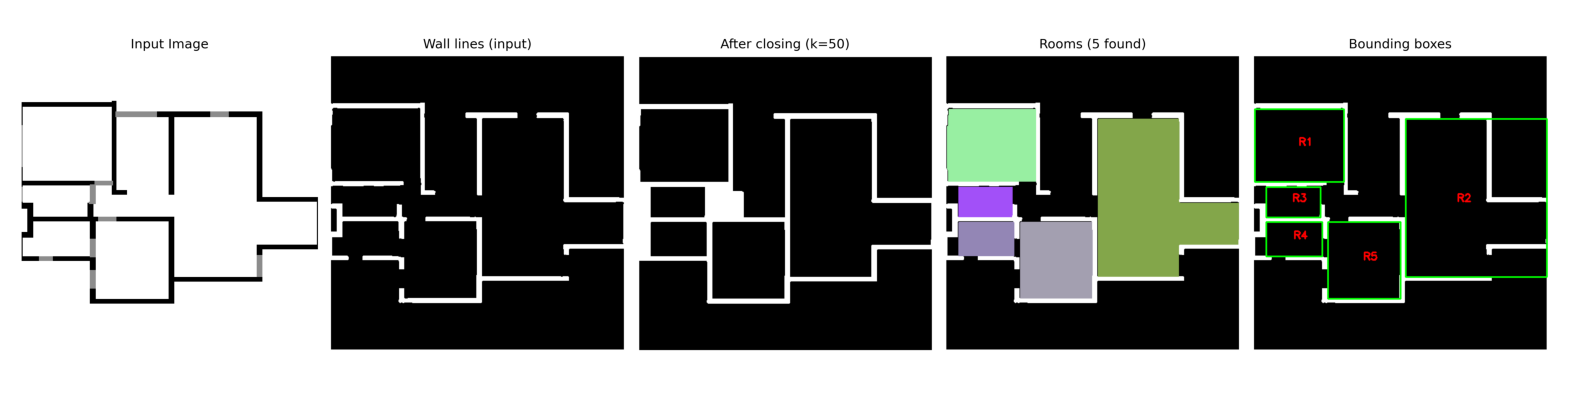

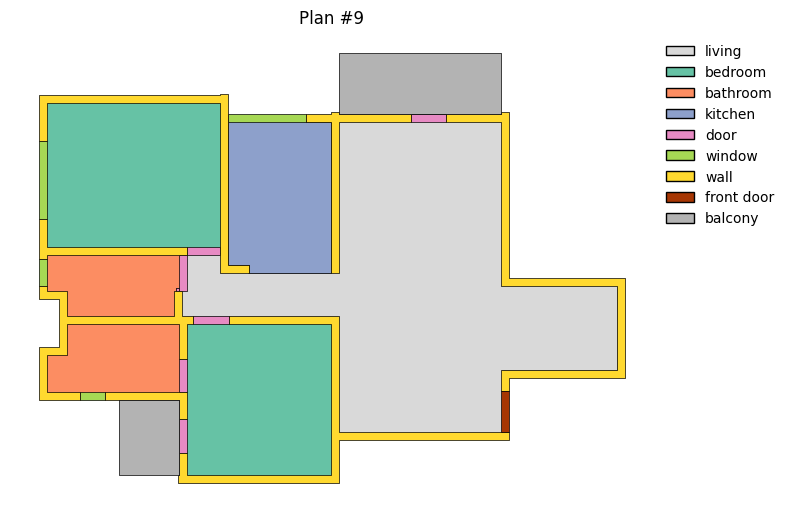

In [22]:
for idx in range(0, 10):
    plan = plans[idx]

    SHAPE = (512, 512)

    img = get_2d_plan(plan, show=False)
    img_path = f'plans/plan_{idx}.png'
    cv2.imwrite(img_path, img)

    # pred_graph = build_graph(img_path)   # your existing function
    pred_graph = build_graph(img_path, border=3, kernel_size=50, iterations=1, min_room_area = 10, max_room_area=50000)

    img = cv2.imread('room_detection.png')
    # set fig size to 10x10 inches

    pred_wall = predict(img_path, show=False)  # your existing function
    rooms      = find_room_boundaries(img_path, pred_wall, border=3, kernel_size=50, iterations=1, min_room_area=10, max_room_area=50000)  # already returns rooms
    metrics    = validate_graph(plan, rooms, pred_graph, shape=(512, 512))
    print(metrics)

    plt.figure(figsize=(20, 20))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # plot the original plot_plan
    ax = plot_plan(plan, title=f'Plan #{idx}')
    plt.show()